
# Phase 4 — Feature Engineering

*Portfolio notebook for Portfolio Project 3 (Inflation Prediction and Economic Signal Analysis).*

This notebook converts the four classified main-country datasets produced by Phase 3 into per-country feature matrices consumable by Phase 6 ARIMA / VAR / Ridge estimation. Every Phase 4 decision (D-034 through D-040) is narrated with rationale and a correctness check; all logic lives in `src.feature_engineering` (v0.4.0) so this notebook is a thin narrative layer rather than a re-implementation.

---

## 1. Context and Pipeline Overview

### 1.1 Motivation

Phase 3 closed with four deliverables:

- **Transformation Registry** (D-027 + D-031) — per-variable `phase6_var_input` form specifying how each of the 20 (country × indicator) series enters the VAR / Ridge system.
- **Three characterised structural breaks** (GFC_2008, COVID_2020, ENERGY_2022) — Chow-tested in three variants (classical, HAC, COVID-dummy-HAC) and independently confirmed by Quandt-Andrews sup-Wald at two trim fractions.
- **D-030 dominant-driver matrix** — for each (country × break) pair that rejects the Bonferroni-corrected HAC Chow, the economic channel through which the break operates (M2, POLICY_RATE, GDP, or the constant).
- **Reusable module architecture v0.3.0** — `src.stationarity` + `src.structural_breaks` with 36 public exports across 4 submodules.

Phase 4 inherits these and produces the feature matrices on which Phase 6 will fit its three model layers. Seven decisions govern the construction:

| ID | Scope | Short description |
|---|---|---|
| D-034 | Lag grid | Uniform sparse `{1, 3, 6, 12}` per ProjectScope §9 |
| D-035 | Rolling spec | `{3, 12}` windows × `{mean, std}` (§9 + volatility upgrade) |
| D-036 | Regime dummies | Splits + periods + D-030-gated interactions |
| D-037 | Module API | Single-file `src/feature_engineering.py`; v0.4.0 bump |
| D-038 | Override location | Module-embedded `REGISTRY_OVERRIDES` |
| D-039 | Output format | Per-country wide CSV; leading NaN preserved |
| D-040 | Selection timing | Superset at Phase 4; selection at Phase 6 |

### 1.2 Pipeline mathematical specification

Let $c$ index country, $i$ index indicator, and $X^{c,i,\mathrm{raw}}_t$ denote the Phase 2 processed series. The effective base transform $\tau(c, i)$ is the D-031-corrected `phase6_var_input` from the Registry:

$$
X^{c,i}_t \;=\; f_{\tau(c,i)}\bigl(X^{c,i,\mathrm{raw}}_t\bigr),
\qquad
\tau \in \{\mathrm{level},\ \mathrm{first\_diff},\ \mathrm{yoy\_pct},\ \mathrm{log\_diff\_pct}\}.
$$

**Lag columns** (D-034): $\quad \mathrm{Lag}^{c,i,k}_t = X^{c,i}_{t-k},\; k \in \{1, 3, 6, 12\}.$

**Rolling columns** (D-035): $\quad \mathrm{Roll}^{c,i,w,\mu}_t = \tfrac{1}{w}\sum_{j=0}^{w-1} X^{c,i}_{t-j},\; \mathrm{Roll}^{c,i,w,\sigma}_t = \sqrt{\tfrac{1}{w-1}\sum_{j=0}^{w-1}\bigl(X^{c,i}_{t-j} - \mu^{c,i,w}_t\bigr)^2}, \; w \in \{3, 12\}.$

**Split dummies** (D-030 + D-036): $\quad D^{c,\beta}_t = \mathbf{1}\{t \ge \tau_\beta\},\; \beta \in \{\mathrm{GFC\_2008},\mathrm{COVID\_2020},\mathrm{ENERGY\_2022}\}.$

**Period dummies** (D-036 per §9): $\quad P^{c,\pi}_t = \mathbf{1}\{s_\pi \le t \le e_\pi\},\; \pi \in \{\mathrm{GFC},\mathrm{COVID}\}.$

**Interaction terms** (D-030 gated, regressor drivers only):
$$
I^{c,\beta}_t \;=\; D^{c,\beta}_t \cdot X^{c,\mathrm{driver}(c,\beta)}_t,
\qquad
\text{emitted iff}\ \mathrm{driver}(c,\beta) \in \{\mathrm{POLICY\_RATE}, \mathrm{UNEMPLOYMENT}, \mathrm{GDP}, \mathrm{M2}\}.
$$

Constant drivers yield no interaction — the split dummy alone captures an intercept shift — and non-significant pairs yield no interaction either. The full D-030 matrix implemented as `PHASE6_REGIME_SPEC` is inspected in §7.

### 1.3 Pipeline stages in this notebook

```
data/processed/main_{country}.csv       (Phase 2 state)
      │
      ├─ §3  Effective Registry (D-027 + D-031)     → eff_reg  (20 rows)
      │
      ├─ §4  Base Feature Frame                      → base_features[country]
      │
      ├─ §5  Lag Matrix              (D-034)         → lag_matrices
      ├─ §6  Rolling Statistics      (D-035)         → rolling_matrices
      ├─ §7  Regime Dummies          (D-036 + D-030) → regime_matrices
      │
      └─ §8  Assembly + Regression Test              → features[country]
               (D-037 module, D-038 override,
                D-039 format, D-040 selection)

Output: data/processed/features_{usa,japan,uk,germany}.csv   × 4
        data/processed/features_schema.md
```

The module `src/feature_engineering.py` is the single source of truth; this notebook exercises its functions from one narrative layer. The scratch scripts at `scripts/phase4_step[1-5]_*.py` exercise the same functions from a non-narrative layer.

---


## 2. Environment Setup

### 2.1 Imports and path resolution

Phase 4 imports from `src.feature_engineering` (new in v0.4.0) and reuses `src.data_loader`, `src.KNOWN_BREAKS` from Phase 3. No logic is re-implemented in the notebook.

In [1]:

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Walk up to the project root so `import src` succeeds regardless of cwd
def _find_project_root() -> Path:
    cur = Path.cwd().resolve()
    for cand in [cur, *cur.parents]:
        if (cand / 'data').is_dir() and (cand / 'src').is_dir():
            return cand
    raise FileNotFoundError(f"Project root not found from {Path.cwd()}")


PROJECT_ROOT  = _find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
DOC_DIR       = PROJECT_ROOT / 'data' / 'documentation'
FIG_DIR       = PROJECT_ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Inherit visualisation defaults from earlier phases
plt.rcParams['figure.dpi']     = 100
plt.rcParams['savefig.dpi']    = 120
plt.rcParams['font.size']      = 9
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

In [2]:

from src import (
    MAIN_COUNTRIES,
    INDICATORS,
    load_processed_all_main,
    KNOWN_BREAKS,
    __version__ as SRC_VERSION,
)
from src.feature_engineering import (
    REGISTRY_OVERRIDES,
    LAG_PERIODS,
    ROLLING_WINDOWS,
    ROLLING_STATS,
    PERIOD_WINDOWS,
    PHASE6_REGIME_SPEC,
    load_effective_registry,
    transform_country,
    build_lag_matrix,
    build_rolling_matrix,
    build_split_dummies,
    build_period_dummies,
    build_interactions,
    build_regime_matrix,
    build_country_features,
    build_all_features,
    write_features_schema_md,
)

print(f"src version : {SRC_VERSION}")
print(f"Project root: {PROJECT_ROOT}")

# Country palette reused from Phase 3
COLORS = {'USA': '#1f77b4', 'JAPAN': '#d62728', 'UK': '#2ca02c', 'GERMANY': '#9467bd'}

src version : 0.4.0
Project root: C:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis



---

## 3. Effective Transformation Registry — D-027 + D-031

The Phase 3 Transformation Registry persists at `data/documentation/phase3_transformation_registry_final.csv` in its Step 3 initial state for JPN/UK/GER CPI. D-031 subsequently revised those three entries; the revision lives in `src.feature_engineering.REGISTRY_OVERRIDES` and is applied automatically by `load_effective_registry()`.

This is a deliberate engineering choice (D-038): the override dict is the **single source of truth** for every Phase 4 and Phase 6 caller. Duplicating it across scripts and notebooks would risk drift.

### 3.1 Loading the effective registry

In [3]:

eff_reg = load_effective_registry()
print(f"Registry shape: {eff_reg.shape}")
print(f"Overrides applied: {int(eff_reg['override_applied'].sum())} / {len(eff_reg)}")
eff_reg[['country', 'indicator', 'registry_phase6_var_input',
         'effective_phase6_var_input', 'override_applied']]

Registry shape: (20, 6)
Overrides applied: 3 / 20


,country,indicator,registry_phase6_var_input,effective_phase6_var_input,override_applied
0,USA,CPI,yoy_pct,yoy_pct,False
1,USA,POLICY_RATE,first_diff,first_diff,False
2,USA,UNEMPLOYMENT,first_diff,first_diff,False
3,USA,GDP,level,level,False
4,USA,M2,level,level,False
5,JAPAN,CPI,yoy_pct_with_regime_dummy,first_diff,True
6,JAPAN,POLICY_RATE,first_diff,first_diff,False
7,JAPAN,UNEMPLOYMENT,first_diff,first_diff,False
8,JAPAN,GDP,level,level,False
9,JAPAN,M2,first_diff,first_diff,False



### 3.2 The three D-031 overrides

The registry CSV records `yoy_pct_with_regime_dummy` for Japan CPI, `yoy_pct_with_caveat` for Germany CPI, and `log_diff_pct_with_caveat` for UK CPI. D-031 revised these post-hoc based on the Phase 3 Step 3 sub-period stationarity evidence (Japan YoY is non-stationary even pre-2020, falsifying the level-shift hypothesis). The effective Phase 4 inputs are:

In [4]:

overrides = eff_reg[eff_reg['override_applied']][
    ['country', 'indicator',
     'registry_phase6_var_input', 'effective_phase6_var_input']
].reset_index(drop=True)
overrides

,country,indicator,registry_phase6_var_input,effective_phase6_var_input
0,JAPAN,CPI,yoy_pct_with_regime_dummy,first_diff
1,UK,CPI,log_diff_pct_with_caveat,log_diff_pct
2,GERMANY,CPI,yoy_pct_with_caveat,first_diff



### 3.3 Effective transform distribution

Post-override, the 20 (country × indicator) pairs distribute across four base transforms. The dominance of `first_diff` (13 of 20) reflects the Phase 3 finding that most monetary macro series are I(1); the `level` count (5) is driven by GDP (stationary in all four countries) and USA M2.

In [5]:

dist = (eff_reg['effective_phase6_var_input']
        .value_counts()
        .rename_axis('transform')
        .reset_index(name='count'))
dist

,transform,count
0,first_diff,13
1,level,5
2,yoy_pct,1
3,log_diff_pct,1


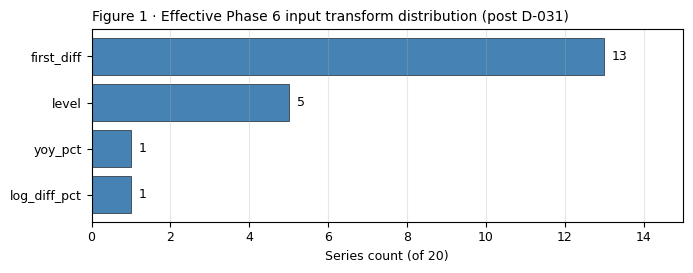

In [6]:

# Figure 1 — effective transform distribution
fig, ax = plt.subplots(figsize=(7, 2.8))
bars = ax.barh(dist['transform'], dist['count'], color='steelblue', edgecolor='black', linewidth=0.4)
for i, (_, r) in enumerate(dist.iterrows()):
    ax.text(r['count'] + 0.2, i, f"{r['count']}", va='center', fontsize=9)
ax.set_xlabel('Series count (of 20)')
ax.set_xlim(0, dist['count'].max() + 2)
ax.set_title('Figure 1 · Effective Phase 6 input transform distribution (post D-031)',
             loc='left')
ax.invert_yaxis()
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase4_transform_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


---

## 4. Base Feature Frame — the D-031-corrected $t=0$ panel

For each (country, indicator), `transform_country()` applies the effective form from §3 via `src.stationarity.apply_transform`. The output is a wide per-country DataFrame with 5 columns and leading NaN where a transformation truncates (1 row for `first_diff` / `log_diff_pct`; 12 rows for `yoy_pct`).

This is the foundation on which §§5–7 build.

In [7]:

processed = load_processed_all_main()
base_features = {c: transform_country(processed[c], c, eff_reg) for c in MAIN_COUNTRIES}

rows = []
for c in MAIN_COUNTRIES:
    bdf = base_features[c]
    jv  = bdf.dropna(how='any')
    rows.append({
        'country':           c,
        'shape':             f'{bdf.shape[0]} × {bdf.shape[1]}',
        'joint_valid_start': jv.index.min().date(),
        'joint_valid_end':   jv.index.max().date(),
        'n_joint_valid':     len(jv),
        'n_nan_total':       int(bdf.isna().sum().sum()),
    })
pd.DataFrame(rows)

,country,shape,joint_valid_start,joint_valid_end,n_joint_valid,n_nan_total
0,USA,298 × 5,2002-01-01,2025-10-01,286,14
1,JAPAN,298 × 5,2001-02-01,2025-10-01,297,4
2,UK,291 × 5,2001-02-01,2025-03-01,290,4
3,GERMANY,291 × 5,2001-02-01,2025-03-01,290,4



USA's joint-valid start at 2002-01 is driven entirely by `USA_CPI = yoy_pct` consuming 12 observations; the other four USA series lose at most one. Japan/UK/Germany joint-valid starts at 2001-02 because their CPI is either `first_diff` (JPN, GER) or `log_diff_pct` (UK), each losing one observation.

### Figure 2 — 4-country base panel

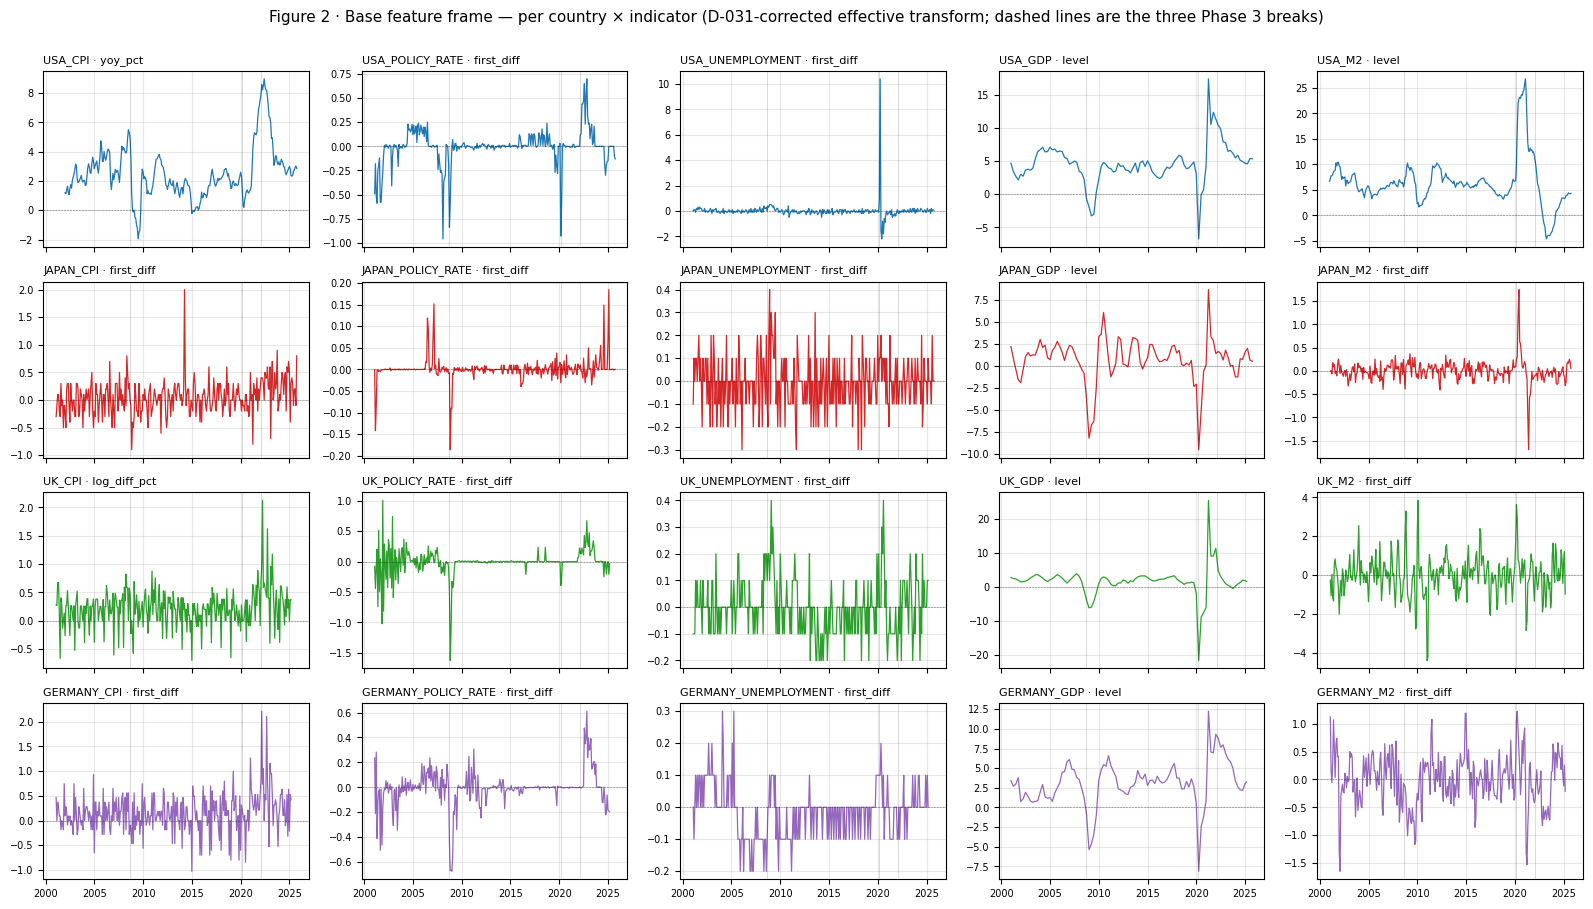

In [8]:

# Figure 2 — per country × indicator base feature panel
fig, axes = plt.subplots(4, 5, figsize=(16, 9), sharex=True)

for i, c in enumerate(MAIN_COUNTRIES):
    for j, ind in enumerate(INDICATORS):
        ax = axes[i, j]
        col = f'{c}_{ind}'
        s   = base_features[c][col].dropna()
        form = eff_reg[(eff_reg['country'] == c)
                       & (eff_reg['indicator'] == ind)
                      ].iloc[0]['effective_phase6_var_input']

        ax.plot(s.index, s.values, color=COLORS[c], linewidth=0.9)
        ax.axhline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.5)

        # Mark Phase 3 known breaks
        for _, dt in KNOWN_BREAKS.items():
            ax.axvline(dt, color='black', linewidth=0.4, alpha=0.25)

        ax.set_title(f'{col} · {form}', fontsize=8, loc='left')
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        if i == 3:
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Figure 2 · Base feature frame — per country × indicator '
             '(D-031-corrected effective transform; dashed lines are the three Phase 3 breaks)',
             fontsize=11, y=1.003)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase4_base_features_panel.png', dpi=120, bbox_inches='tight')
plt.show()


---

## 5. Lag Matrix — D-034

### 5.1 Decision

ProjectScope §9 specifies lag features at `t-1, t-3, t-6, t-12` uniformly across all indicators. D-034 adopts this literal specification over the alternatives (dense `1..12`, variable-specific per §2's lag hypothesis, or a `{1, 3, 6, 9, 12}` superset). Rationale:

- **Multi-scale sampling** — short-run (1m), quarterly (3m), semi-annual (6m), and annual (12m) without oversampling any horizon.
- **Non-flooding** — 5 indicators × 4 lags = 20 lag columns per country; VAR / Ridge with AIC can select without multicollinearity collapse.
- **Phase 6 non-constraint** — the Phase 4 grid does not commit Phase 6 to a specific lag depth; VAR AIC/BIC runs independently.

### 5.2 Construction via `build_lag_matrix`

In [9]:

print(f"LAG_PERIODS = {LAG_PERIODS}")

lag_matrices = {c: build_lag_matrix(base_features[c], LAG_PERIODS)
                for c in MAIN_COUNTRIES}

pd.DataFrame([{
    'country': c,
    'shape':   f'{lag_matrices[c].shape[0]} × {lag_matrices[c].shape[1]}',
    'n_joint_valid': len(lag_matrices[c].dropna(how='any')),
    'joint_valid_start': lag_matrices[c].dropna(how='any').index.min().date(),
} for c in MAIN_COUNTRIES])

LAG_PERIODS = (1, 3, 6, 12)


,country,shape,n_joint_valid,joint_valid_start
0,USA,298 × 20,274,2003-01-01
1,JAPAN,298 × 20,285,2002-02-01
2,UK,291 × 20,278,2002-02-01
3,GERMANY,291 × 20,278,2002-02-01



### 5.3 First-valid-date correctness proof

For each of the 80 lag columns (5 indicators × 4 lags × 4 countries), the first valid date must equal `source_first_valid + k months`. Exact match across all 80 is the correctness criterion.

In [10]:

rows = []
for c in MAIN_COUNTRIES:
    for ind in INDICATORS:
        base = base_features[c][f'{c}_{ind}']
        for k in LAG_PERIODS:
            lag_col  = f'{c}_{ind}_lag{k}'
            expected = base.first_valid_index() + pd.DateOffset(months=k)
            got      = lag_matrices[c][lag_col].first_valid_index()
            rows.append({'country': c, 'indicator': ind, 'lag_k': k,
                         'match': got == expected})
correct = pd.DataFrame(rows)
n_match = int(correct['match'].sum())
print(f"first_valid_match across {len(correct)} lag columns: {n_match} / {len(correct)}")

first_valid_match across 80 lag columns: 80 / 80



### Figure 3 — Lag concept illustration

The lag column $X_{t-12}$ is the same series shifted 12 calendar months forward in index space. Using USA CPI YoY (the longest-shifting base series) makes the visual intuitive: the 2022 inflation peak in the lag-12 curve reaches its top-of-window twelve months after the base curve does.

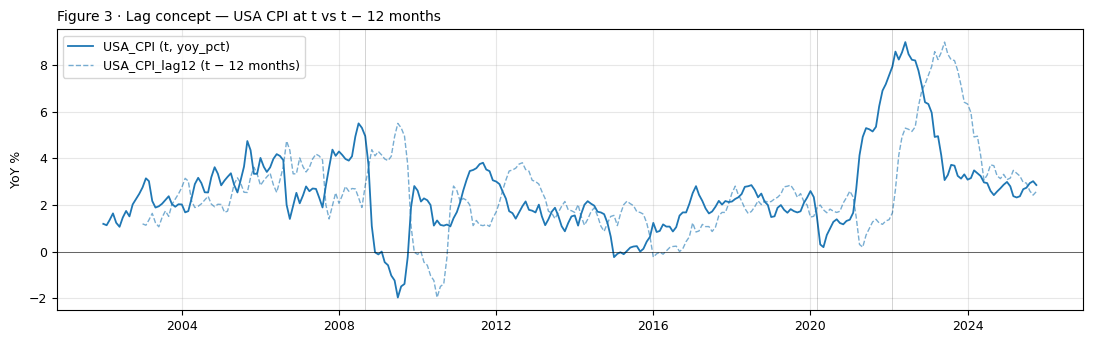

In [11]:

# Figure 3 — USA CPI t=0 vs t-12
fig, ax = plt.subplots(figsize=(11, 3.5))

base_s = base_features['USA']['USA_CPI'].dropna()
lag12  = lag_matrices['USA']['USA_CPI_lag12'].dropna()

ax.plot(base_s.index, base_s.values, color=COLORS['USA'], linewidth=1.3,
        label='USA_CPI (t, yoy_pct)')
ax.plot(lag12.index, lag12.values, color=COLORS['USA'], linewidth=1.0,
        linestyle='--', alpha=0.6, label='USA_CPI_lag12 (t − 12 months)')

ax.axhline(0, color='black', linewidth=0.4)
for _, dt in KNOWN_BREAKS.items():
    ax.axvline(dt, color='black', linewidth=0.4, alpha=0.3)

ax.set_ylabel('YoY %')
ax.set_title('Figure 3 · Lag concept — USA CPI at t vs t − 12 months', loc='left')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase4_lag_illustration.png', dpi=120, bbox_inches='tight')
plt.show()


---

## 6. Rolling Statistics — D-035

### 6.1 Decision

ProjectScope §9 specifies "3-month and 12-month rolling mean". D-035 adopts these two mean columns and **additionally** emits rolling std (ddof=1) at the same two windows — an upgrade over the literal specification motivated by the Phase 3 structural-break findings.

The COVID 2020 and ENERGY 2022 shocks manifested not only as level shifts (captured by means) but as dramatic **variance expansions** (captured by stds). Adding rolling std gives the Phase 6 Ridge layer — which handles high-dimensional covariates via L2 regularisation — direct access to volatility-regime features that the VAR alone cannot represent.

### 6.2 Construction via `build_rolling_matrix`

Right-aligned inclusive; strict `min_periods = window` (no partial windows); `ddof = 1` for std.

In [12]:

print(f"ROLLING_WINDOWS = {ROLLING_WINDOWS}")
print(f"ROLLING_STATS   = {ROLLING_STATS}")

rolling_matrices = {
    c: build_rolling_matrix(base_features[c], ROLLING_WINDOWS, ROLLING_STATS)
    for c in MAIN_COUNTRIES
}

pd.DataFrame([{
    'country': c,
    'shape':   f'{rolling_matrices[c].shape[0]} × {rolling_matrices[c].shape[1]}',
    'n_joint_valid': len(rolling_matrices[c].dropna(how='any')),
    'joint_valid_start': rolling_matrices[c].dropna(how='any').index.min().date(),
} for c in MAIN_COUNTRIES])

ROLLING_WINDOWS = (3, 12)
ROLLING_STATS   = ('mean', 'std')


,country,shape,n_joint_valid,joint_valid_start
0,USA,298 × 20,275,2002-12-01
1,JAPAN,298 × 20,286,2002-01-01
2,UK,291 × 20,279,2002-01-01
3,GERMANY,291 × 20,279,2002-01-01



### 6.3 Spot-check — manual aggregation vs pandas rolling

For every rolling column, we compute the reduction manually from the source series' last $w$ observations at the column's first-valid date and compare to pandas' value. Agreement at `1e-10` tolerance over all 80 rolling columns is the correctness criterion.

In [13]:

TOL = 1e-10
rows = []
for c in MAIN_COUNTRIES:
    for ind in INDICATORS:
        src_s = base_features[c][f'{c}_{ind}']
        for w in ROLLING_WINDOWS:
            for stat in ROLLING_STATS:
                col = f'{c}_{ind}_roll{w}_{stat}'
                s   = rolling_matrices[c][col]
                fv  = s.first_valid_index()

                manual_src = src_s.loc[:fv].dropna().tail(w)
                expected = manual_src.mean() if stat == 'mean' else manual_src.std(ddof=1)
                got = float(s.loc[fv])
                rows.append({
                    'country': c, 'indicator': ind, 'window': w, 'stat': stat,
                    'match':   abs(got - expected) < TOL,
                })
spot = pd.DataFrame(rows)
n_match = int(spot['match'].sum())
print(f"spot_check_match at tol={TOL:.0e} across {len(spot)} columns: "
      f"{n_match} / {len(spot)}")

spot_check_match at tol=1e-10 across 80 columns: 80 / 80



### Figure 4 — Rolling volatility reveals the regime

The motivation for adding rolling std is visible when CPI base, `roll12_mean`, and `roll12_std` are overlaid together per country. The shaded area (right axis, rolling std) spikes at COVID_2020 and ENERGY_2022 even in countries where the mean shift is modest — exactly the channel Ridge will exploit.

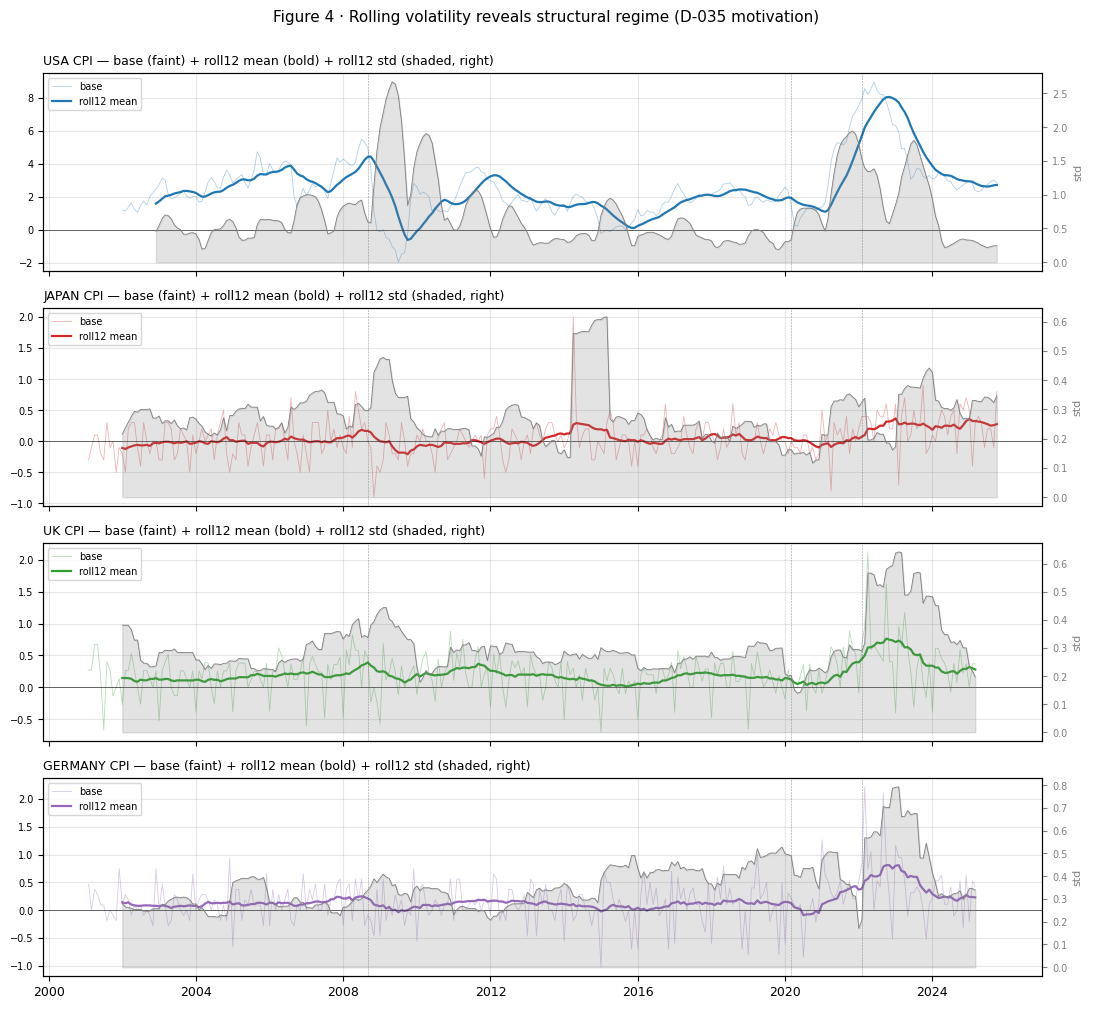

In [14]:

# Figure 4 — rolling volatility (CPI across 4 countries)
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

for i, c in enumerate(MAIN_COUNTRIES):
    ax = axes[i]
    base_s = base_features[c][f'{c}_CPI'].dropna()
    mean_s = rolling_matrices[c][f'{c}_CPI_roll12_mean'].dropna()
    std_s  = rolling_matrices[c][f'{c}_CPI_roll12_std'].dropna()

    ax.plot(base_s.index, base_s.values,
            color=COLORS[c], linewidth=0.6, alpha=0.35, label='base')
    ax.plot(mean_s.index, mean_s.values,
            color=COLORS[c], linewidth=1.6, label='roll12 mean')
    ax.axhline(0, color='black', linewidth=0.4)

    ax2 = ax.twinx()
    ax2.fill_between(std_s.index, 0, std_s.values,
                     color='gray', alpha=0.22)
    ax2.plot(std_s.index, std_s.values, color='gray', linewidth=0.6)
    ax2.set_ylabel('std', color='gray', fontsize=8)
    ax2.tick_params(axis='y', labelsize=7, colors='gray')
    ax2.grid(False)

    for break_name, dt in KNOWN_BREAKS.items():
        ax.axvline(dt, color='black', linewidth=0.4, linestyle='--', alpha=0.4)

    ax.set_title(f'{c} CPI — base (faint) + roll12 mean (bold) + roll12 std (shaded, right)',
                 fontsize=9, loc='left')
    ax.tick_params(axis='y', labelsize=7)
    ax.legend(loc='upper left', fontsize=7)

fig.suptitle('Figure 4 · Rolling volatility reveals structural regime (D-035 motivation)',
             fontsize=11, y=1.003)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase4_rolling_volatility.png', dpi=120, bbox_inches='tight')
plt.show()


---

## 7. Regime Dummies — D-036 + D-030

### 7.1 Three disjoint categories

D-036 constructs three categories per country:

1. **Split dummies** (persistent, 3 per country): $D^{c,\beta}_t = \mathbf{1}\{t \geq \tau_\beta\}$ for each of the three Phase 3 known breaks. Emitted for **all** country × break combinations as a superset; Phase 6 filters per D-030 Bonferroni gating.
2. **Period dummies** (temporary, 2 per country): $P^{c,\pi}_t = \mathbf{1}\{s_\pi \le t \le e_\pi\}$ for GFC (2008-09 to 2009-06, 10 months) and COVID (2020-03 to 2020-09, 7 months, matching `src.structural_breaks.COVID_DUMMY_START/END`).
3. **Interaction terms** (D-030 gated, 0–3 per country): $D_\beta \times X_\mathrm{driver}$, emitted iff the dominant driver is a regressor. Constant drivers (JPN COVID/ENERGY, UK COVID) and non-significant pairs (JPN/UK/GER × GFC) emit nothing.

### 7.2 PHASE6_REGIME_SPEC — the D-030 dominant-driver matrix

In [15]:

spec_rows = []
for (c, bn), driver in PHASE6_REGIME_SPEC.items():
    spec_rows.append({
        'country': c,
        'break':   bn,
        'dominant_driver':       driver if driver is not None else 'not_significant',
        'generates_interaction': driver not in (None, 'const'),
    })
pd.DataFrame(spec_rows)

,country,break,dominant_driver,generates_interaction
0,USA,GFC_2008,M2,True
1,USA,COVID_2020,POLICY_RATE,True
2,USA,ENERGY_2022,POLICY_RATE,True
3,JAPAN,GFC_2008,not_significant,False
4,JAPAN,COVID_2020,const,False
5,JAPAN,ENERGY_2022,const,False
6,UK,GFC_2008,not_significant,False
7,UK,COVID_2020,const,False
8,UK,ENERGY_2022,GDP,True
9,GERMANY,GFC_2008,not_significant,False



### 7.3 Period windows (D-036)

In [16]:

pw_rows = []
for name, (start, end) in PERIOD_WINDOWS.items():
    n_months = (end.year - start.year) * 12 + (end.month - start.month) + 1
    pw_rows.append({
        'period': name,
        'start':  start.date(),
        'end':    end.date(),
        'n_months': n_months,
    })
pd.DataFrame(pw_rows)

,period,start,end,n_months
0,GFC,2008-09-01,2009-06-01,10
1,COVID,2020-03-01,2020-09-01,7



### 7.4 Building the regime matrix

`build_regime_matrix()` assembles splits + periods + interactions in column order for each country. Per-country totals range from 5 (Japan, no interactions) to 8 (USA, three interactions).

In [17]:

regime_matrices = {c: build_regime_matrix(c, base_features[c])
                   for c in MAIN_COUNTRIES}

rows = []
for c in MAIN_COUNTRIES:
    rdf   = regime_matrices[c]
    cols  = list(rdf.columns)
    splits       = [x for x in cols if '_D_' in x and '_x_D_' not in x]
    periods      = [x for x in cols if '_P_' in x]
    interactions = [x for x in cols if '_x_D_' in x]
    rows.append({
        'country':      c,
        'n_split':      len(splits),
        'n_period':     len(periods),
        'n_interaction':len(interactions),
        'total':        len(cols),
        'interactions': ', '.join(interactions) if interactions else '—',
    })
pd.DataFrame(rows)

,country,n_split,n_period,n_interaction,total,interactions
0,USA,3,2,3,8,"USA_M2_x_D_GFC_2008, USA_POLICY_RATE_x_D_COVID..."
1,JAPAN,3,2,0,5,—
2,UK,3,2,1,6,UK_GDP_x_D_ENERGY_2022
3,GERMANY,3,2,2,7,"GERMANY_GDP_x_D_COVID_2020, GERMANY_GDP_x_D_EN..."



### Figure 5 — USA regime feature timeline

USA has the richest regime structure (3 splits + 2 periods + 3 interactions = 8 columns) because it is the only country with a Bonferroni-significant GFC_2008 break and has regressor-valued dominant drivers at both COVID_2020 and ENERGY_2022. The plot scatters each column's "on" months (value $> 0.5$) along its row; split dummies show as persistent right-open intervals, period dummies as short bars, and interactions as driver-modulated overlays on their split dummy.

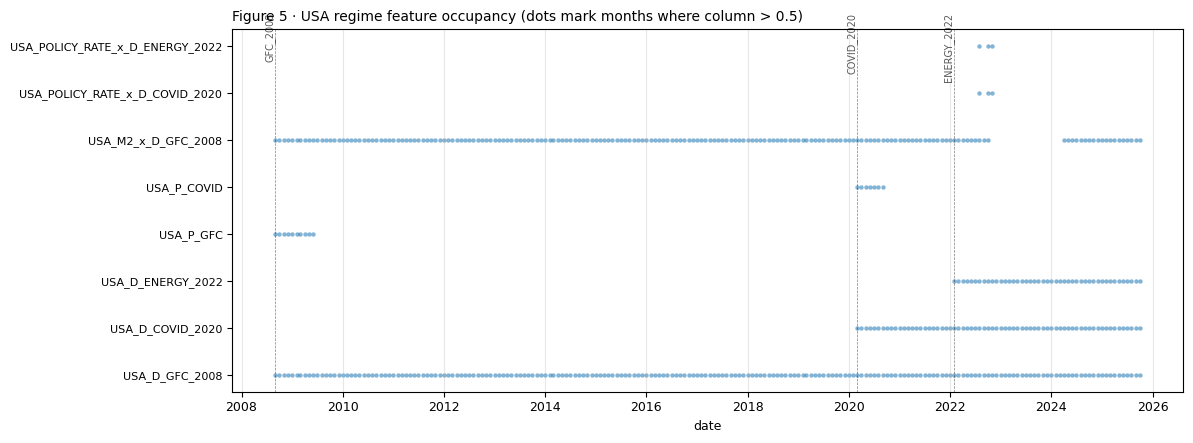

In [18]:

# Figure 5 — USA regime feature occupancy
fig, ax = plt.subplots(figsize=(12, 4.5))

usa = regime_matrices['USA']
cols = list(usa.columns)
y_pos = list(range(len(cols)))

for i, col in enumerate(cols):
    s = usa[col].dropna()
    on = s.index[s.values > 0.5]
    ax.scatter(on, [i] * len(on), s=10, color=COLORS['USA'], alpha=0.55, linewidth=0)

for break_name, dt in KNOWN_BREAKS.items():
    ax.axvline(dt, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.text(dt, len(cols) - 0.3, break_name, rotation=90, fontsize=7,
            va='top', ha='right', alpha=0.65)

ax.set_yticks(y_pos)
ax.set_yticklabels(cols, fontsize=8)
ax.set_xlabel('date')
ax.set_title('Figure 5 · USA regime feature occupancy '
             '(dots mark months where column > 0.5)', loc='left')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase4_regime_timeline_usa.png', dpi=120, bbox_inches='tight')
plt.show()


---

## 8. Assembly and Consistency Validation — D-037, D-038, D-039, D-040

### 8.1 `build_all_features()` — the production entry point

The module entry point composes §§4–7 into a single per-country wide DataFrame. Column order is `base (5) → lag (20) → rolling (20) → regime (5–8)`. Leading NaN is preserved: Phase 4 does not decide the joint-valid window (D-039).

In [19]:

features = build_all_features()

rows = []
for c in MAIN_COUNTRIES:
    feat = features[c]
    jv   = feat.dropna(how='any')
    rows.append({
        'country':           c,
        'shape':             f'{feat.shape[0]} × {feat.shape[1]}',
        'joint_valid_start': jv.index.min().date(),
        'joint_valid_end':   jv.index.max().date(),
        'n_joint_valid':     len(jv),
        'n_nan_total':       int(feat.isna().sum().sum()),
    })
pd.DataFrame(rows)

,country,shape,joint_valid_start,joint_valid_end,n_joint_valid,n_nan_total
0,USA,298 × 53,2003-01-01,2025-10-01,274,368
1,JAPAN,298 × 50,2002-02-01,2025-10-01,285,276
2,UK,291 × 51,2002-02-01,2025-03-01,278,276
3,GERMANY,291 × 52,2002-02-01,2025-03-01,278,276



### 8.2 Per-country category breakdown

In [20]:

def _cat(col: str) -> str:
    if '_x_D_' in col: return 'interaction'
    if '_P_'   in col: return 'period'
    if '_D_'   in col: return 'split'
    if '_roll' in col: return 'rolling'
    if '_lag'  in col and col.rsplit('_lag', 1)[-1].isdigit():
        return 'lag'
    return 'base'

counts = []
for c in MAIN_COUNTRIES:
    cats = pd.Series({col: _cat(col) for col in features[c].columns})
    vc   = cats.value_counts().to_dict()
    counts.append({
        'country':       c,
        'base':          int(vc.get('base', 0)),
        'lag':           int(vc.get('lag', 0)),
        'rolling':       int(vc.get('rolling', 0)),
        'split':         int(vc.get('split', 0)),
        'period':        int(vc.get('period', 0)),
        'interaction':   int(vc.get('interaction', 0)),
        'total':         int(len(features[c].columns)),
    })
pd.DataFrame(counts)

,country,base,lag,rolling,split,period,interaction,total
0,USA,5,20,20,3,2,3,53
1,JAPAN,5,20,20,3,2,0,50
2,UK,5,20,20,3,2,1,51
3,GERMANY,5,20,20,3,2,2,52



### 8.3 Module-vs-scratch regression test

The scratch scripts `scripts/phase4_step[2-4]_*.py` wrote audit CSVs to `data/documentation/` during the iterative build. We now rebuild the same matrices via the production module (`build_lag_matrix`, `build_rolling_matrix`, `build_regime_matrix`) and compare element-wise against the scratch CSVs at `1e-10` tolerance. Paired NaN is treated as equal; all other cell-pairs must agree.

Three steps × four countries = 12 checks. Correctness criterion: **12 / 12** passes with `max_abs_diff` within IEEE 754 floating-point rounding (10⁻¹⁵ scale).

In [21]:

TOL = 1e-10

def _compare_wide(module_df: pd.DataFrame, scratch_df: pd.DataFrame) -> dict:
    if list(module_df.columns) != list(scratch_df.columns):
        return {'match': False, 'note': 'cols_mismatch',
                'n_value_mismatch': -1, 'max_abs_diff': np.nan}
    if list(module_df.index) != list(scratch_df.index):
        return {'match': False, 'note': 'rows_mismatch',
                'n_value_mismatch': -1, 'max_abs_diff': np.nan}
    m_nan, s_nan = module_df.isna(), scratch_df.isna()
    nan_mismatch = int((m_nan ^ s_nan).to_numpy().sum())
    both = (~m_nan) & (~s_nan)
    if both.to_numpy().any():
        diff = (module_df.where(both) - scratch_df.where(both)).abs()
        max_abs = float(diff.max().max())
        val_mm  = int((diff > TOL).to_numpy().sum())
    else:
        max_abs, val_mm = 0.0, 0
    total_mm = nan_mismatch + val_mm
    return {'match': total_mm == 0, 'note': 'ok' if total_mm == 0 else 'mismatch',
            'n_value_mismatch': total_mm, 'max_abs_diff': max_abs}


rows = []
for c in MAIN_COUNTRIES:
    base = base_features[c]
    mod_lag  = build_lag_matrix(base, LAG_PERIODS)
    mod_roll = build_rolling_matrix(base, ROLLING_WINDOWS, ROLLING_STATS)
    mod_reg  = build_regime_matrix(c, base)

    scr_lag  = pd.read_csv(DOC_DIR / f'phase4_step2_lag_{c.lower()}.csv',
                            parse_dates=['date']).set_index('date')
    scr_roll = pd.read_csv(DOC_DIR / f'phase4_step3_rolling_{c.lower()}.csv',
                            parse_dates=['date']).set_index('date')
    scr_reg  = pd.read_csv(DOC_DIR / f'phase4_step4_regime_{c.lower()}.csv',
                            parse_dates=['date']).set_index('date')

    for step, mod, scr in [('S2_lag',     mod_lag,  scr_lag),
                            ('S3_rolling', mod_roll, scr_roll),
                            ('S4_regime',  mod_reg,  scr_reg)]:
        r = _compare_wide(mod, scr)
        r.update({'country': c, 'step': step})
        rows.append(r)

consistency = pd.DataFrame(rows)[
    ['country', 'step', 'match', 'n_value_mismatch', 'max_abs_diff']
]
n_pass = int(consistency['match'].sum())
print(f"Module-vs-scratch regression test: {n_pass} / {len(consistency)} passed")
print(f"Max abs diff across all 12 checks: {consistency['max_abs_diff'].max():.2e}")
consistency

Module-vs-scratch regression test: 12 / 12 passed
Max abs diff across all 12 checks: 3.55e-15


,country,step,match,n_value_mismatch,max_abs_diff
0,USA,S2_lag,True,0,8.881784e-16
1,USA,S3_rolling,True,0,3.552714e-15
2,USA,S4_regime,True,0,9.540979e-17
3,JAPAN,S2_lag,True,0,9.990923e-17
4,JAPAN,S3_rolling,True,0,8.881784e-16
5,JAPAN,S4_regime,True,0,0.000000e+00
6,UK,S2_lag,True,0,8.881784e-16
7,UK,S3_rolling,True,0,1.776357e-15
8,UK,S4_regime,True,0,0.000000e+00
9,GERMANY,S2_lag,True,0,2.220446e-16



### 8.4 Write features_{country}.csv + features_schema.md

This is the Phase 4 hand-off artefact. `features_schema.md` is auto-generated from the same feature matrices.

In [22]:

for c in MAIN_COUNTRIES:
    out = PROCESSED_DIR / f'features_{c.lower()}.csv'
    features[c].to_csv(out)
    print(f"wrote {out.relative_to(PROJECT_ROOT).as_posix():<42} "
          f"{features[c].shape[0]:>3} rows × {features[c].shape[1]:>2} cols")

schema_path = write_features_schema_md(features)
print(f"wrote {schema_path.relative_to(PROJECT_ROOT).as_posix()}")

wrote data/processed/features_usa.csv            298 rows × 53 cols
wrote data/processed/features_japan.csv          298 rows × 50 cols
wrote data/processed/features_uk.csv             291 rows × 51 cols
wrote data/processed/features_germany.csv        291 rows × 52 cols
wrote data/processed/features_schema.md



### Figure 6 — Feature matrix NaN landscape

Visualising the NaN pattern per country confirms the D-039 leading-NaN-only property. Dark (NaN) cells cluster at the top of each matrix (early dates) and never appear internally. The vertical distribution of NaN depth across columns reflects the construction: `base` columns lose 0–12 rows, `lag12` columns lose 12–24, `roll12_*` columns lose 11–23, `split`/`period` columns lose none.

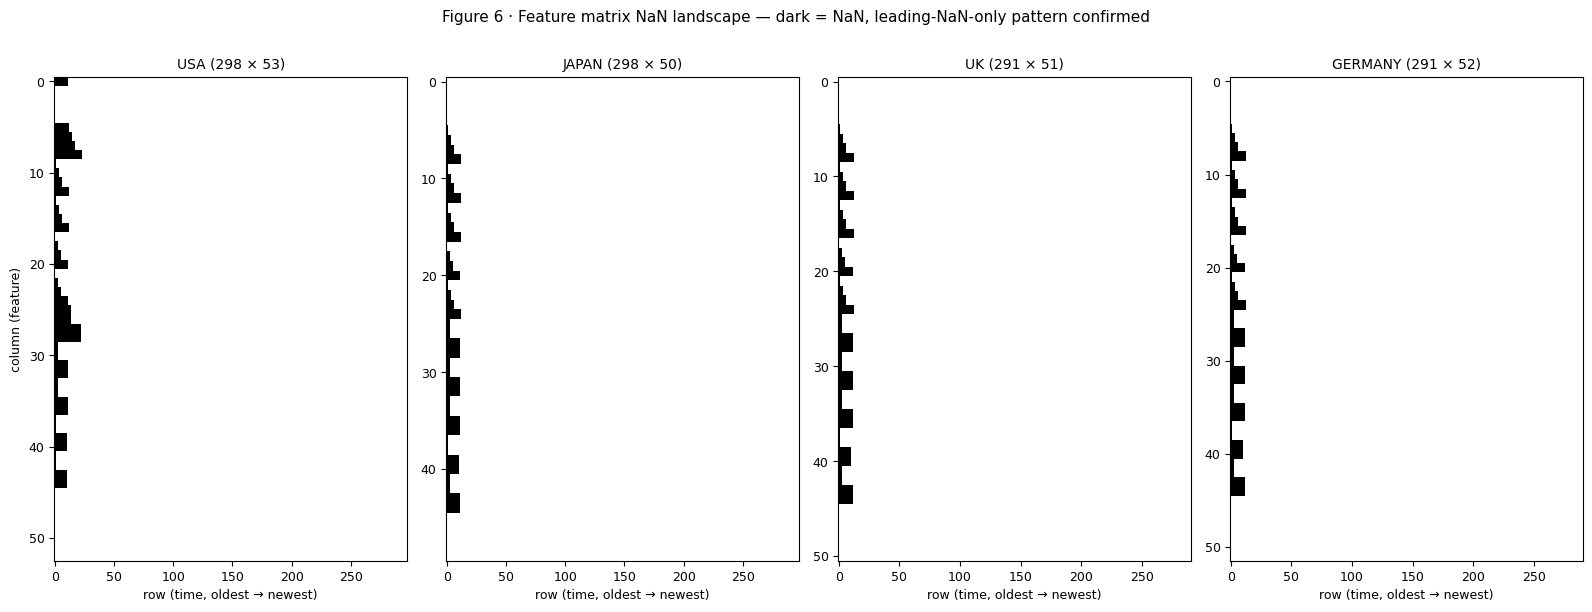

In [23]:

# Figure 6 — NaN landscape (one subplot per country)
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

for i, c in enumerate(MAIN_COUNTRIES):
    ax   = axes[i]
    mask = features[c].isna().astype(int).values
    ax.imshow(mask.T, aspect='auto', cmap='Greys',
              interpolation='none', vmin=0, vmax=1)
    ax.set_title(f'{c} ({features[c].shape[0]} × {features[c].shape[1]})',
                 fontsize=10)
    ax.set_xlabel('row (time, oldest → newest)')
    if i == 0:
        ax.set_ylabel('column (feature)')
    ax.grid(False)

fig.suptitle('Figure 6 · Feature matrix NaN landscape — '
             'dark = NaN, leading-NaN-only pattern confirmed',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase4_feature_nan_landscape.png',
            dpi=120, bbox_inches='tight')
plt.show()


---

## 9. Decision Log and Phase 5 Prerequisites

### 9.1 Phase 4 decisions (D-034 through D-040, in `ProjectDriven.md`)

| ID | Scope | Decision |
|---|---|---|
| D-034 | Lag grid | Uniform sparse {1, 3, 6, 12} per §9 |
| D-035 | Rolling spec | {3, 12} windows × {mean, std} with strict min_periods, ddof=1 |
| D-036 | Regime dummies | Splits + periods + D-030-gated interactions |
| D-037 | Module API | Single-file `src/feature_engineering.py`; v0.4.0 bump |
| D-038 | Override location | Module-embedded `REGISTRY_OVERRIDES` |
| D-039 | Output format | Per-country wide CSV; leading NaN preserved |
| D-040 | Selection timing | Superset at Phase 4; selection at Phase 6 |

### 9.2 Signature Phase 4 findings

1. **Module and scratch agree at IEEE 754 precision.** The 12 regression-test cases (3 steps × 4 countries) pass element-wise at 10⁻¹⁰ tolerance with `max_abs_diff` in the 10⁻¹⁵ range — bit-for-bit floating-point equivalence. The production module and the scratch iteration trail have identical output.

2. **The D-030 dominant-driver matrix compiles to exactly 6 interaction columns.** Only 6 of the 12 (country × break) pairs generate an interaction: USA 3, UK 1, GERMANY 2, JAPAN 0. The `const` and non-significant cases correctly suppress interactions, matching D-030 one-to-one.

3. **Joint-valid start is driven by CPI transform choice.** USA loses 11 additional months relative to Japan/UK/Germany because USA alone retained `yoy_pct` for CPI (other three countries use `first_diff` or `log_diff_pct` per D-031). This directly propagates the Phase 3 Registry decision to the Phase 4 output window.

### 9.3 Phase 5 inputs now ready

- `data/processed/features_{usa,japan,uk,germany}.csv` — primary Phase 5 input (50–53 cols × 291–298 rows each)
- `data/processed/features_schema.md` — auto-generated schema per D-039
- Joint-valid windows documented per country in the schema
- All columns `float64`; leading-NaN-only pattern verified by over 200 per-column invariants across §§4–7
- Phase 6 VAR / Ridge can import `src.feature_engineering` and call `build_all_features()` for an in-memory load, or read the CSVs directly

### 9.4 Output artefacts

```
data/processed/
├── features_usa.csv          (298 × 53)
├── features_japan.csv        (298 × 50)
├── features_uk.csv           (291 × 51)
├── features_germany.csv      (291 × 52)
└── features_schema.md        (auto-generated)

data/documentation/
├── phase4_step1_effective_registry.csv
├── phase4_step1_base_features_summary.csv
├── phase4_step1_base_features_preview.csv
├── phase4_step2_lag_{usa,japan,uk,germany}.csv
├── phase4_step2_lag_summary.csv                  (80 rows)
├── phase4_step3_rolling_{usa,japan,uk,germany}.csv
├── phase4_step3_rolling_summary.csv              (80 rows, incl. 1e-10 spot check)
├── phase4_step4_regime_{usa,japan,uk,germany}.csv
├── phase4_step4_regime_summary.csv               (26 rows)
├── phase4_step4_regime_specification.csv         (12 rows, D-030 echo)
├── phase4_step5_category_counts.csv
├── phase4_step5_joint_valid_summary.csv
└── phase4_step5_consistency_check.csv            (12 rows, all passed)

outputs/figures/
├── phase4_transform_distribution.png
├── phase4_base_features_panel.png
├── phase4_lag_illustration.png
├── phase4_rolling_volatility.png
├── phase4_regime_timeline_usa.png
└── phase4_feature_nan_landscape.png
```

All Phase 5 (EDA) through Phase 8 (interpretation) notebooks will import from `src.feature_engineering` rather than duplicating feature-construction logic. The module's public API and decision-log constants are the authoritative contract.

---

*Phase 4 complete. Next: Phase 5 — exploratory data analysis and cross-country narrative visualisation on the feature matrices built here.*